<a href="https://colab.research.google.com/github/Anuj04432/Handwritten_Digit_Classification/blob/main/handwritten_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten,Input,Dropout
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [7]:
data = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
(x_train,y_train), (x_test,y_test) = data

print("X_train",x_train.shape)
print("Y_train",y_train.shape)
print("X_test",x_test.shape)
print("y_test",y_test.shape)

X_train (60000, 28, 28)
Y_train (60000,)
X_test (10000, 28, 28)
y_test (10000,)


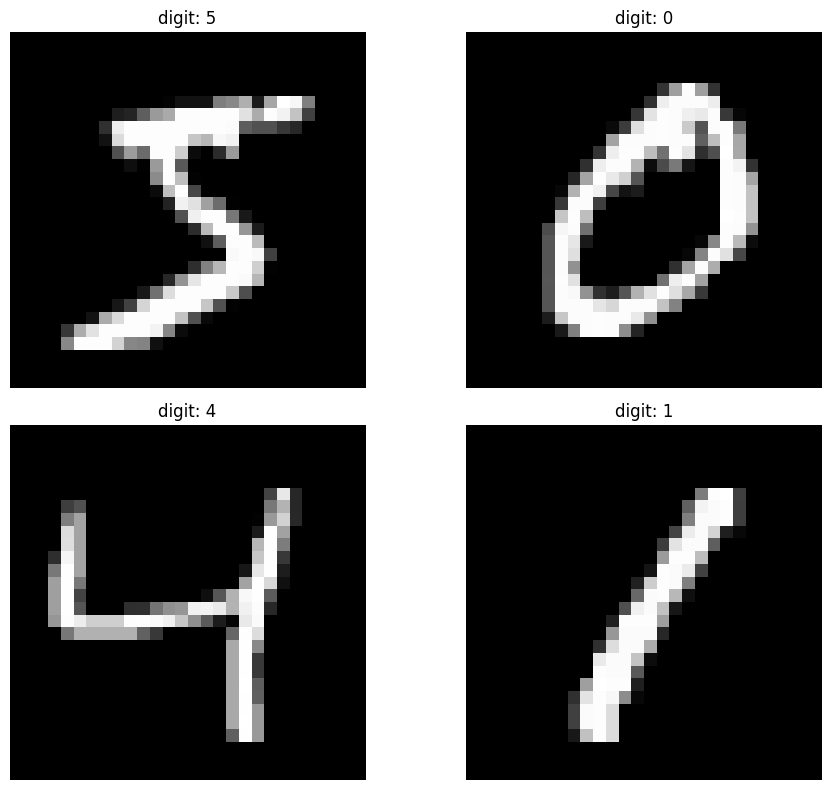

In [13]:
plt.figure(figsize=(10,8))

for i in range(4):
  plt.subplot(2,2,i+1)
  plt.imshow(x_train[i],cmap="grey")
  plt.title(f"digit: {y_train[i]}")
  plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

print("Minimun: ",x_train.min())
print("Maximum: ",x_train.max())

Minimun:  0.0
Maximum:  1.0


In [15]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"]
              )

In [19]:
model_history = model.fit(x_train,y_train,
                          epochs=25,
                          batch_size=50,
                          validation_split=0.2)

Epoch 1/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9678 - loss: 0.1044 - val_accuracy: 0.9710 - val_loss: 0.0960
Epoch 2/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9776 - loss: 0.0719 - val_accuracy: 0.9739 - val_loss: 0.0846
Epoch 3/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9834 - loss: 0.0552 - val_accuracy: 0.9747 - val_loss: 0.0846
Epoch 4/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9860 - loss: 0.0452 - val_accuracy: 0.9694 - val_loss: 0.1040
Epoch 5/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9892 - loss: 0.0336 - val_accuracy: 0.9730 - val_loss: 0.0960
Epoch 6/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9903 - loss: 0.0286 - val_accuracy: 0.9760 - val_loss: 0.0978
Epoch 7/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9736 - val_loss: 0.0955
Epoch 8/25
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9930 - loss: 0.0206 - val_accuracy: 0.

In [20]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9743 - loss: 0.1533
Test Accuracy: 97.43%


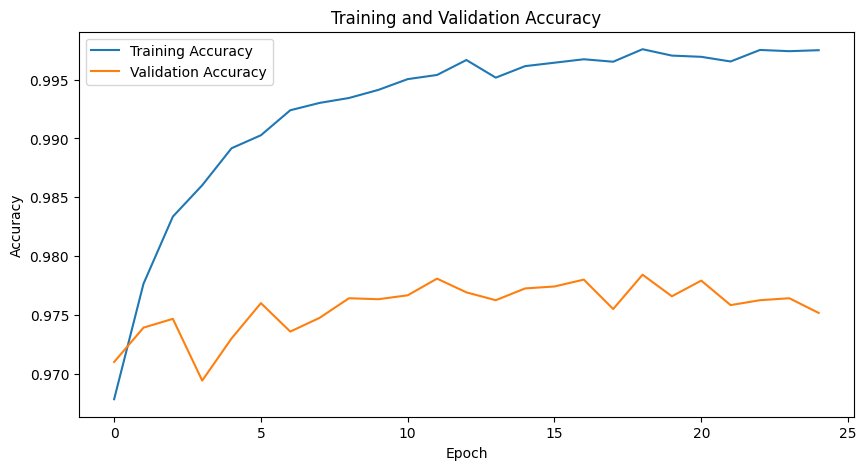

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(model_history.history["accuracy"], label="Training Accuracy")
plt.plot(model_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

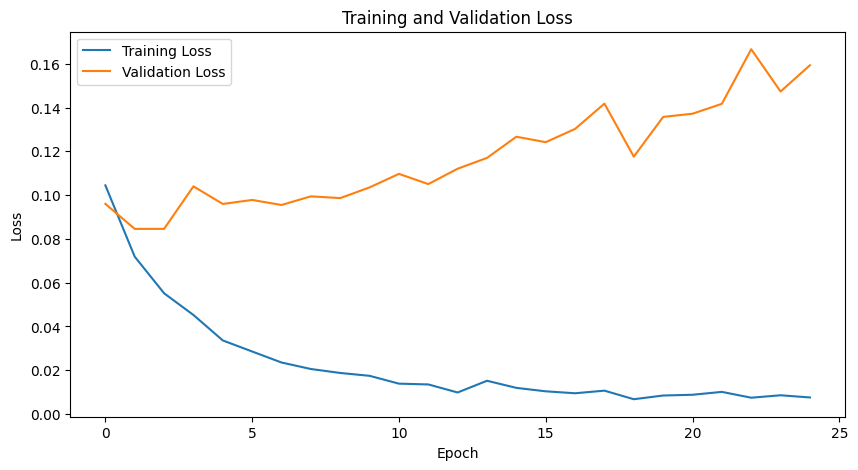

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(model_history.history["loss"], label="Training Loss")
plt.plot(model_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [25]:
dropout_model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(10, activation="softmax")
    ])

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"]
              )

In [26]:
history_dropout = model.fit(x_train,y_train,
                          epochs=10,
                          batch_size=50,
                          validation_split=0.2)

Epoch 1/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9985 - loss: 0.0053 - val_accuracy: 0.9766 - val_loss: 0.1422
Epoch 2/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.9763 - val_loss: 0.1500
Epoch 3/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9976 - loss: 0.0074 - val_accuracy: 0.9790 - val_loss: 0.1411
Epoch 4/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9753 - val_loss: 0.1603
Epoch 5/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9983 - loss: 0.0055 - val_accuracy: 0.9808 - val_loss: 0.1394
Epoch 6/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9972 - loss: 0.0092 - val_accuracy: 0.9729 - val_loss: 0.1723
Epoch 7/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9981 - loss: 0.0053 - val_accuracy: 0.9756 - val_loss: 0.1713
Epoch 8/10
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.